In [2]:
pip install scikit-surprise

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-win_amd64.whl size=1291654 sha256=8aeaffe8a2af58f6b1f55e46ad829f3c50a2e8759cad46344fa4c5c82ad481a5
  Stored in directory: c:\users\ylanj\appdata\local\pip\cache\wheels\75\fa\bc\739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
Note: you may need to restart the kernel to use updated packages.


Evaluating SVD...
Evaluating NMF...
Evaluating SlopeOne...
Evaluating CoClustering...
Evaluating KNNBasic...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
      Algorithm  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE
0           SVD      0.6561     0.8724     0.5140    0.6805
1           NMF      0.6331     0.9074     0.4822    0.7032
2      SlopeOne      0.7164     0.8802     0.5491    0.6830
3  CoClustering      0.8191     0.9198     0.6356    0.7148
4      KNNBasic      0.8768     0.9653     0.6906    0.7618


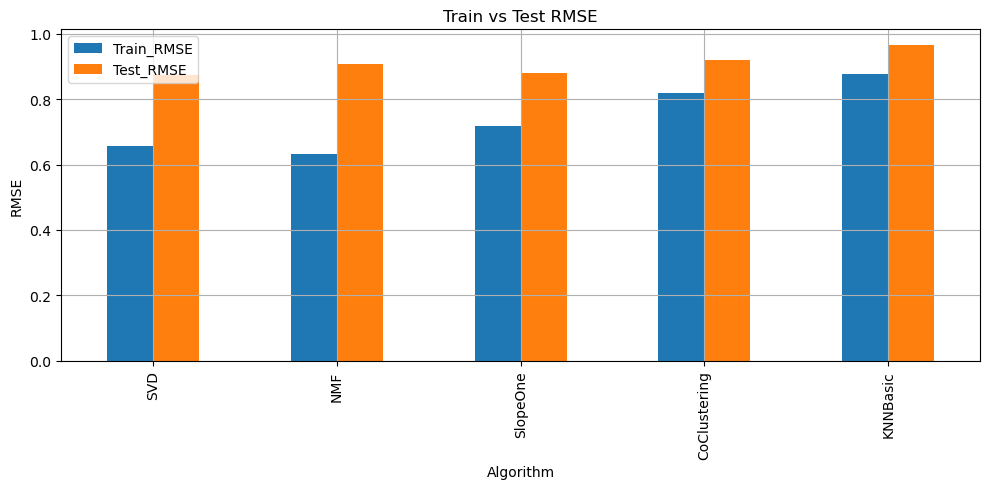

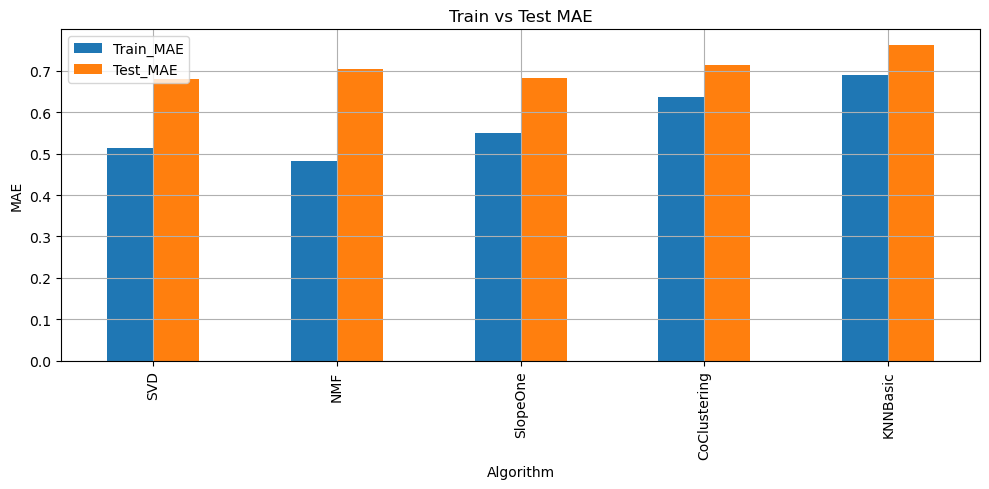

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from surprise import Dataset, Reader, SVD, NMF, SlopeOne, CoClustering, KNNBasic
from surprise.model_selection import cross_validate

# Load and filter dataset
ratings = pd.read_csv("data/ratings.dat", sep="::", engine="python", names=["userID", "itemID", "rating", "timestamp"])
filtered = ratings[(ratings["userID"] <= 1000) & (ratings["itemID"] <= 1000)]

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(filtered[["userID", "itemID", "rating"]], reader)

# Define algorithms (including memory-efficient KNNBasic)
sim_options = {
    "name": "cosine",       # or "msd", "pearson"
    "user_based": False     # set to True for user-user similarity
}

algos = {
    "SVD": SVD(),
    "NMF": NMF(),
    "SlopeOne": SlopeOne(),
    "CoClustering": CoClustering(),
    "KNNBasic": KNNBasic(k=40, sim_options=sim_options)
}

# Evaluate with cross-validation (including training scores)
detailed_results = {}
for name, algo in algos.items():
    print(f"Evaluating {name}...")
    cv = cross_validate(algo, data, measures=["RMSE", "MAE"], cv=3, return_train_measures=True)
    detailed_results[name] = {
        "Train_RMSE": round(cv["train_rmse"].mean(), 4),
        "Test_RMSE": round(cv["test_rmse"].mean(), 4),
        "Train_MAE": round(cv["train_mae"].mean(), 4),
        "Test_MAE": round(cv["test_mae"].mean(), 4)
    }

# Display results
df_detailed = pd.DataFrame(detailed_results).T.reset_index().rename(columns={"index": "Algorithm"})
print(df_detailed)

# Plot RMSE
df_detailed.plot(x="Algorithm", y=["Train_RMSE", "Test_RMSE"], kind="bar", figsize=(10, 5), title="Train vs Test RMSE")
plt.ylabel("RMSE")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot MAE
df_detailed.plot(x="Algorithm", y=["Train_MAE", "Test_MAE"], kind="bar", figsize=(10, 5), title="Train vs Test MAE")
plt.ylabel("MAE")
plt.grid(True)
plt.tight_layout()
plt.show()
